In [1]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from src.green_gecko_model import CAModel, make_seed
from src.fourier import find_peaks, plot_fourier

# Calculating the Fourier spectra
### Load model

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

In [3]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model2/gecko/seed_c/8000.weights.h5")
None

2026-06-17 20:04:11.743261: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-17 20:04:11.743296: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-17 20:04:11.743306: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-17 20:04:11.743332: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-17 20:04:11.743344: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-06-17 20:04:12.166615: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Run model for quite a while
To get burn-in phase (2000 steps), and the spectrum (8000)

In [4]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(22000): # Usually 10000
    x = model(x)
    states.append(tf.identity(x).numpy())

states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end] 
print(states_np.shape)

(22001, 1, 40, 40, 16)


In [5]:
flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)

### Get the spectrum
It's first plotted without a log scaled y-axis. This is helpful to me to know how many peaks we care about. Then plotted with log-scaled y-axis, as is convention.

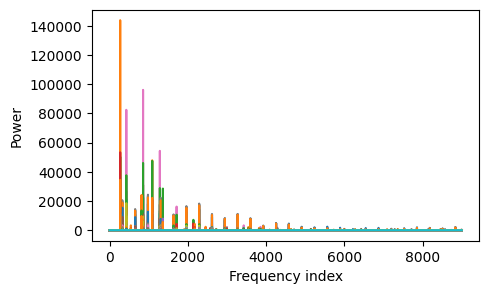

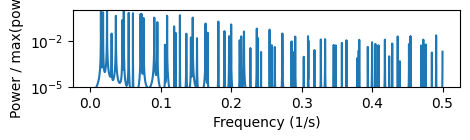

In [6]:
raw_attractor = flattened_attractor_states[4000:] # Usually 2000

power, freqs = plot_fourier(raw_attractor, dt=1.0, filename="version3", reduce_x_by=None, figure_size=(5,1))

Determine how many peaks we should care about. The cut-off point is a bit arbitrary, of course, but helps preserve the lowest frequency peaks, which we care the most about. 

In [7]:
threshold = 0.005
n_over_threshold = freqs[power > threshold].shape
power_over_threshold = power[power > threshold]
freqs_over_threshold = freqs[power > threshold]
print("Frequencies over threshold:", n_over_threshold)
print(freqs_over_threshold)

Frequencies over threshold: (134,)
[0.01499917 0.01505472 0.01511027 0.01516582 0.01522138 0.01527693
 0.01533248 0.017999   0.01805455 0.0181101  0.01816566 0.01822121
 0.01827676 0.01833231 0.02349869 0.02355425 0.0236098  0.02366535
 0.0237209  0.02377646 0.02383201 0.02388756 0.02394311 0.02399867
 0.02405422 0.02410977 0.0302761  0.03033165 0.03616466 0.03622021
 0.03627576 0.03633131 0.03638687 0.03644242 0.03649797 0.03655352
 0.04538637 0.04544192 0.04549747 0.04749736 0.04755291 0.04760847
 0.04766402 0.04771957 0.05449697 0.05455252 0.05460808 0.06060774
 0.07132937 0.07138492 0.07144048 0.07149603 0.07266263 0.07271818
 0.07277373 0.07566246 0.07571802 0.07577357 0.07582912 0.09071718
 0.09077273 0.09082829 0.09088384 0.09093939 0.09099494 0.0910505
 0.09110605 0.09516138 0.09521693 0.09527248 0.09532804 0.10604966
 0.10899394 0.1090495  0.10910505 0.1091606  0.10921615 0.11904894
 0.12121549 0.12727071 0.13632576 0.13638131 0.1428254  0.14288095
 0.14532526 0.14538081 0.145

In [8]:
freqs_over_threshold[find_peaks(power_over_threshold, k=None)], len(freqs_over_threshold[find_peaks(power_over_threshold, k=None)])

(array([0.01516582, 0.01816566, 0.02383201, 0.0302761 , 0.03638687,
        0.04544192, 0.04760847, 0.05455252, 0.06060774, 0.07144048,
        0.07271818, 0.07577357, 0.09088384, 0.09521693, 0.10910505,
        0.11904894, 0.12727071, 0.13638131, 0.14288095, 0.14543636,
        0.15149158, 0.16365757, 0.18182323, 0.19998889, 0.21426587,
        0.21815455, 0.23637576, 0.25454141, 0.30909394, 0.33331482,
        0.38181212, 0.41819899, 0.43636465, 0.4545303 , 0.47275151]),
 35)

### Eliminate harmonics

In [9]:
TOL = 0.0001#0.0002

f = freqs_over_threshold[find_peaks(power_over_threshold, k=None)] #freqs[find_peaks(power, k=9)]

def is_harmonics(f1, f2, tol=TOL):

    for i in range(2, 20):
        if abs(f1*float(i) - f2) < tol:
            return True
        
    return False

frequncy_families = []

f_sorted = sorted(f)

while len(f_sorted) > 0:
    f1 = f_sorted.pop(0)
    family = [f1]
    for f2 in f_sorted:
        if is_harmonics(f1, f2):
            family.append(f2)
            f_sorted.remove(f2)
    frequncy_families.append(family)


Now we have some candidate base frequencies

In [10]:
bases = [family[0] for family in frequncy_families]
bases, len(bases)

([0.015165824120882174,
  0.01816565746347425,
  0.023832009332814843,
  0.07144047552913728,
  0.09088383978667852,
  0.09521693239264485,
  0.10910504971946003,
  0.1190489417254597,
  0.1272707071829343,
  0.13638131214932503,
  0.14543636464640855,
  0.15149158380089994,
  0.16365757457919006,
  0.19998888950613855,
  0.23637575690239432,
  0.3090939392255986,
  0.33331481584356426,
  0.41819898894505864],
 18)

### Eliminate linear combinations, if any
You want the smallest set of these frequencies that create the rest of the frequencies. This is a brute force method, and if the minimal set it really large, then this will not converge in a good amount of time. Luckily for me, nothing higher than a three torus was found, which took tops an hour to find.

In [11]:
def recursive_make_sets(sets, bases, depth):
    if len(sets) == 0:
        sets = sets + [[base] for base in bases]
    
    current_depth = len(sets[0])
    
    if current_depth >= depth:
        return sets
    else:
        new_sets = []
        for set in sets:
            for base in bases:
                if base in set:
                    continue
                new_sets.append(set + [base])
        return recursive_make_sets(new_sets, bases, depth)


two_set = recursive_make_sets([], bases, 2)
three_set = recursive_make_sets(two_set, bases, 3)
len(three_set)

4896

In [12]:
def is_linear_combination(set, f, tol=TOL):
    def recursive_linear_combination(set, f, linear_combo, tol=TOL):
        if len(set) == 0:
            if abs(linear_combo - f) < tol:
                return True
            return False
        s1 = set[0]
        for i in range(-10, 60):
            if recursive_linear_combination(set[1:], f, linear_combo + s1*float(i), tol):
                return True
        return False
    return recursive_linear_combination(set, f, 0, tol)

def count_explains(set, bases):
    count = 0
    for f in bases:
        if f in set:
            continue
        if is_linear_combination(set, f):
            count += 1
    return count

minimal_sets = recursive_make_sets([], bases, 2)

found_minimal_set = False

possible_base_frequency_sets = []

for tori_number in range(2,len(bases)):
    goal_count = len(bases) - tori_number

    for set in minimal_sets:
        count = count_explains(set, bases)
        if count >= goal_count:
            found_minimal_set = True
            possible_base_frequency_sets.append(set)

    if found_minimal_set:
        print("Minimal set is found at tori number", tori_number)
        break
    else:
        print("Increasing tori number to ", tori_number + 1)
    minimal_sets = recursive_make_sets(minimal_sets, bases, tori_number + 1)


Increasing tori number to  3
Minimal set is found at tori number 3


In [13]:
len(possible_base_frequency_sets), len(minimal_sets)

(546, 4896)